In [ ]:
import pandas as pd

df = pd.read_csv(r'breast-cancer.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.shape

(569, 32)

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [ ]:
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [ ]:
df.isnull().sum().sum()

0

In [ ]:
df.shape

(569, 32)

In [ ]:
df=df.drop('id',axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['diagnosis']=encoder.fit_transform(df['diagnosis'])

In [ ]:
X=df.drop('diagnosis',axis=1)
y=df['diagnosis']

In [ ]:
X.shape

(569, 30)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

ALL DATA

In [ ]:
from sklearn.svm import SVC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm=SVC()
svm.fit(X_train,y_train)

y_pred=svm.predict(X_test)

acc= accuracy_score(y_test,y_pred)
classification= classification_report(y_test,y_pred)

print(f"Accuracy at {i} no of components is {acc}")
print("Classification report:")
print(classification)


Accuracy at 1 no of components is 0.9473684210526315
Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        71
           1       1.00      0.86      0.92        43

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


for i in [25,20,15,10,5,2,1]:
    pca= PCA(n_components=i)
    X_pca=pca.fit_transform(X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    svm=SVC()
    svm.fit(X_train,y_train)

    y_pred=svm.predict(X_test)

    acc= accuracy_score(y_test,y_pred)
    classification= classification_report(y_test,y_pred)

    print(f"Accuracy at {i} no of components is {acc}")
    print("Classification report:")
    print(classification)

    print('*********************************************')


Accuracy at 25 no of components is 0.9736842105263158
Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

*********************************************
Accuracy at 20 no of components is 0.9736842105263158
Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

*********************************************
Accuracy at 15 no of components is 0.9824561403508771
Classification report:
              precision

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


for i in [25,20,15,10,5,2,1]:
    pca= PCA(n_components=i)
    X_pca=pca.fit_transform(X_scaled)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

    random_model=RandomForestClassifier()
    random_model.fit(X_train,y_train)

    y_pred=random_model.predict(X_test)

    acc= accuracy_score(y_test,y_pred)
    classification= classification_report(y_test,y_pred)

    print(f"Accuracy at {i} no of components is {acc}")
    variance_ratio = sum(pca.explained_variance_ratio_)
    print(f"\nComponents: {i}, Variance retained: {variance_ratio:.2%}")

    print("Classification report:")
    print(classification)

    print('*********************************************')


Accuracy at 25 no of components is 0.9473684210526315

Components: 25, Variance retained: 99.94%
Classification report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

*********************************************
Accuracy at 20 no of components is 0.956140350877193

Components: 20, Variance retained: 99.56%
Classification report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

*********************************************
Accuracy at 15 

PLOT FOR BEST PCA

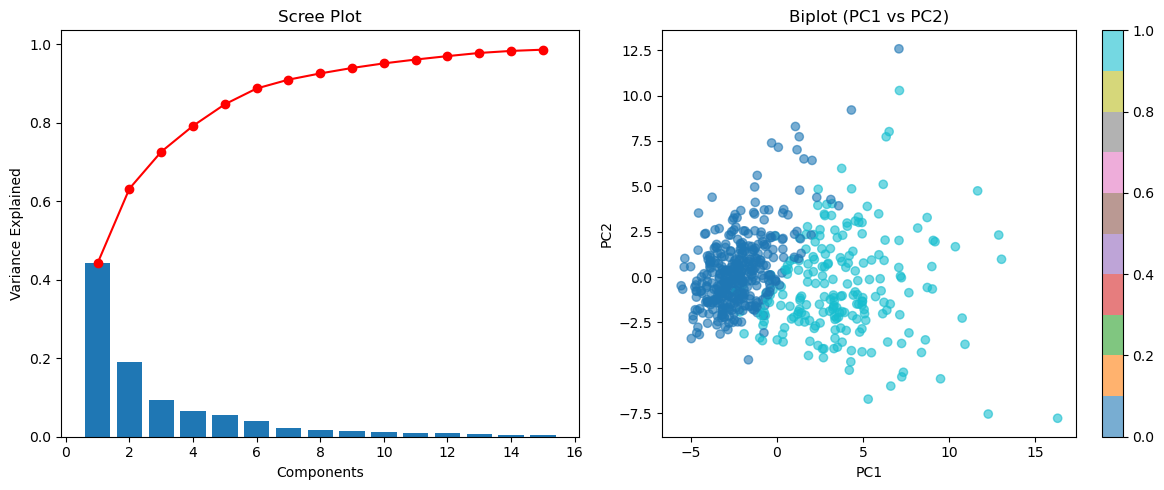

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.bar(range(1, 16), pca.explained_variance_ratio_)
plt.plot(range(1, 16), np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.xlabel('Components')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')

# Biplot - use y directly
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y, cmap='tab10', alpha=0.6)  # y has 569 samples
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot (PC1 vs PC2)')
plt.colorbar(scatter)

plt.tight_layout()
plt.show()